# Sub-Agent 를 활용한 컨텍스트 격리(Context Isolation) & 작업 위임(Task Delegation)

**LangChain**을 활용하여 복잡한 에이전트 시스템에서 **Context Isolation(컨텍스트 격리)** 및 **Task Delegation(작업 위임)** 을 구현하는 방법을 다룹니다.

**🏆 핵심 내용**

*   **Context Isolation**: Sub-agent를 활용한 독립적 작업 처리 및 컨텍스트 충돌 방지
*   **Sub-agent 구성**: `SubAgent` 타입 정의, 프롬프트 및 도구 할당
*   **Task Delegation**: Supervisor Agent의 작업 위임 도구(`task`) 개발
*   **실습**: Supervisor-Research Sub-agent 협업 시스템 구축
*   **LangChain 1.0**: `create_agent` 등 최신 API 적용

## Context Isolation: Sub-agent 활용

![](./assets/agent_header_subagent.png)


**Context Isolation**은 복잡한 시스템에서 컨텍스트 충돌 및 오염을 방지하기 위해 각 작업을 독립된 **Sub-agent**에게 위임하는 전략입니다.

*   **필요성**: 단일 컨텍스트 윈도우 내 다목적 혼재로 인한 성능 저하 방지
*   **해결책**: 특화된 Sub-agent가 격리된 환경에서 작업 수행
*   **참고**: [LangChain Context Engineering](https://blog.langchain.com/context-engineering-for-agents/), [Anthropic Multi-agent System](https://www.anthropic.com/engineering/multi-agent-research-system)

---

### Sub-agent 위임 구조

![./assets/subagents.png](./assets/subagents.png)

*   **구조**: `subagent_type`을 Key로 하는 **Agent Registry** 활용
*   **동작**:
    1.  Main Agent가 `task(description, subagent_type)` 호출
    2.  Sub-agent가 분리된 컨텍스트에서 작업 수행
    3.  결과를 `ToolMessage`로 반환
*   **장점**: 역할 분리, 시스템 안정성 및 확장성 향상

하위 에이전트를 통한 컨텍스트 격리를 위한 작업 위임 도구.

이 모듈은 격리된 컨텍스트를 가진 하위 에이전트를 생성하고 관리하기 위한 핵심 인프라를 제공합니다. 

하위 에이전트는 특정 작업 설명만 포함된 깨끗한 컨텍스트 창으로 작동함으로써 **컨텍스트 충돌을 방지**합니다.

## Step 2: Task Delegation 도구 개발

Sub-agent에게 작업을 위임하고 결과를 수신하는 `task` 도구를 구현합니다.

*   **기능**: 작업 설명(`description`)과 Sub-agent 타입(`subagent_type`)을 입력받아 위임
*   **Context Isolation**:
    *   부모 에이전트의 히스토리를 제외하고, 작업 설명만 포함된 **새로운 컨텍스트** 생성
    *   Sub-agent는 격리된 환경에서 실행
*   **결과 반환**:
    *   `Command` 객체를 통해 파일 변경 사항(`files`) 병합
    *   Sub-agent의 최종 응답을 `ToolMessage`로 변환하여 부모에게 전달

In [1]:
# Sub-agent 사용법 프롬프트 출력 함수 호출, Supervisor Agent 프롬프트 설계 참고 목적
from util.messages_in_jupyter import show_prompt

from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS_KOR

show_prompt(SUBAGENT_USAGE_INSTRUCTIONS_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  서브에이전트에 작업을 위임할 수 있습니다.                                                                      │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  당신의 역할은 구체적인 연구 작업을 서브에이전트에 위임하여 연구를 조정하는 것입니다.                           │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: 전문 서브에이전트에 연구 작업 위임                                    │
│     - description: 명확하고 구체적인 연구 질문 또는 작업                                                        │
│     - subagent_type: 사용할 에이전트 유형 (예: "research-agent")                                                │
│  2. **think_tool(reflection)**: 각 위임 작업의 결과를 반성하고 다음 단계를 계획                                 │
│     - reflection: 작업 결과와 다음 단계에 대한 상세한 반성                                                      │
│                                                                                                                 │
│  **병렬 연구**: 여러 독립적인 연구 방향을 식별하면 한 응답에서 여러 **task** 도구 호출을                        │
│  수행하여 병렬 실행을 활성화하십시오. 반복당 최대 {max_concurrent_research_units}개의                           │
│  병렬 에이전트를 사용하십시오.                                                                                  │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **작업 위임 예산** (과도한 위임 방지):                                                                         │
│  - **집중 연구 선호** - 단순 질문에는 단일 에이전트 사용, 명확히 유리하거나 사용자                              │
│    요청에 따라 여러 독립 연구 방향이 있을 때만 여러 에이전트 사용                                               │
│  - **충분할 때 중단** - 과도한 연구 금지, 충분한 정보가 있으면 중단                                             │
│  - **반복 제한** - 적절한 출처를 찾지 못하면 {max_researcher_iterations}회 작업 위임 후 중단                    │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **단순 사실 확인, 목록, 순위**는 단일 서브에이전트 사용 가능:                                                  │
│  - *예시*: "샌프란시스코 상위 10개 커피숍 목록" → 서브에이전트 1개 사용,                                        │
│    `findings_coffee_shops.md`에 저장                                                                            │
│                                                                                                                 │
│  **비교**는 비교 요소마다 서브에이전트 사용 가능:                                                               │
│  - *예시*: "OpenAI vs Anthropic vs DeepMind의 AI 안전 접근법 비교" → 서브에이전트 3개 사용                      │
│  - 별도 파일에 결과 저장: `findings_openai_safety.md`, `findings_anthropic_safety.md`,                          │
│    `findings_deepmind_safety.md`                                                                                │
│                                                                                                                 │
│  **다면

In [4]:
from deep_agents_from_scratch.prompts import TASK_DESCRIPTION_PREFIX_KOR


show_prompt(TASK_DESCRIPTION_PREFIX_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  격리된 컨텍스트를 가진 전문 서브에이전트에 작업을 위임합니다. 위임에 사용 가능한 에이전트:                     │
│  {other_agents}                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Sub-agent 정의 및 설정

`_create_task_tool`을 사용하여 구체적인 Sub-agent를 정의하고 시스템에 통합합니다.

*   **Sub-agent의 이중 역할**:
    *   **도구**: Supervisor에게 호출 방법 제공
    *   **에이전트**: 독립적 프롬프트 및 도구 세트로 작업 수행
*   **예시: Research Sub-agent**:
    *   `description`: 단일 주제 연구 위임 명시
    *   `tools`: `web_search` 할당
    *   **효과**: 특정 작업에 한정된 독립 컨텍스트에서 동작하여 충돌 방지
*   **Supervisor 프롬프트**: Sub-agent 호출 방법 및 병렬 처리 지침 포함 필수

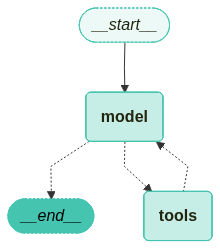

In [5]:
from deep_agents_from_scratch.deep_agent_sub_agent_delegation_graph import DeepAgentSubAgentDelegationGraph

workflow = DeepAgentSubAgentDelegationGraph(recursion_limit=100)

workflow.show_graph()

In [6]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "Give me an overview of Model Context Protocol (MCP).",
        }
    ],
}

workflow.invoke(inputs)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  task (call_T08AUqBOUNKwxUYFUtZoPq83)
 Call ID: call_T08AUqBOUNKwxUYFUtZoPq83
  Args:
    description: Provide an overview of the Model Context Protocol (MCP), including its purpose, key features, and applications.
    subagent_type: research-agent

🔄 Node: model in [tools] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  web_search (call_h019vjuOfZAYZIIlAr1xIIAr)
 Call ID: call_h019vjuOfZAYZIIlAr1xIIAr
  Args:
    query: Model Context Protocol MCP overview purpose key features applications

🔄 Node: tools in [tools] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: web_search

The Model Context Protocol (MCP) is an open standard protocol dev

{'messages': [HumanMessage(content='Give me an overview of Model Context Protocol (MCP).', additional_kwargs={}, response_metadata={}, id='3bc40507-486e-44e1-b7f1-735b538e1223'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 604, 'total_tokens': 644, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fff3498a90', 'id': 'chatcmpl-DhEosC82BfS4JsoBclo7AWehEJnkH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e406e-6ef0-7610-a2dd-d5d0a5bbce86-0', tool_calls=[{'name': 'task', 'args': {'description': 'Provide an overview of the Model Context Protocol (MCP), including its purpose, key features, and applications.'

실행 결과 확인하기: https://smith.langchain.com/public/4dee1f7f-d8d4-4241-a053-cc7ba8678822/r